In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Reading in Data Files

In [3]:
results_dir = 'results/Known_Mols'

bayesian_biased = pd.read_excel(f'{results_dir}/Known_Bias.xlsx').drop(columns=['Unnamed: 0'])
bayesian_unbiased = pd.read_excel(f'{results_dir}/Known_Unbias.xlsx').drop(columns=['Unnamed: 0'])

known_src = pd.read_excel(f'{results_dir}/KnownMol.xlsx').drop(columns=['Unnamed: 0']).rename(columns={'kinase inhibition likeliness' : 'kinase', 'similarity' : 'sim'})


In [4]:
bayesian_biased.columns, known_src.columns

(Index(['known', 'sim', 'created', 'kinase', 'rings', 'weight', 'csp3',
        'hallkier', 'laputeASA', 'alicarbo', 'alihetero', 'alirings',
        'amidebonds', 'arocarbo', 'arohetero', 'arorings', 'stereocenter',
        'bridgehead', 'hba', 'hbd', 'rotatable', 'qed', 'SAS', 'logP'],
       dtype='object'),
 Index(['known mol', 'sim', 'smiles', 'distance', 'count', 'frequency', 'Class',
        'qed', 'logP', 'SAS', 'result', 'rings', 'weight', 'csp3', 'hallkier',
        'laputeASA', 'alicarbo', 'alihetero', 'alirings', 'amidebonds',
        'arocarbo', 'arohetero', 'arorings', 'stereocenter', 'bridgehead',
        'hba', 'hbd', 'rotatable', 'kinase'],
       dtype='object'))

In [5]:
def get_features(feature_name, dataframe_list = [bayesian_biased, bayesian_unbiased, known_src]):
    '''Gets feature of interest from each of the dataframes in the list'''
    ## If you change the order of the dataframe list, you will need to update the indices below
    feature_dict = {
        'Biased' : dataframe_list[0][feature_name].values,
        'Unbiased' : dataframe_list[1][feature_name].values,
        'Known SRC' : dataframe_list[2][feature_name].values
    }
    
    return feature_dict

def get_similarity(feature_name ,dataframe_list = [bayesian_unbiased, bayesian_biased, known_src]):
    ''' Same as get features but meant for just similarity as they were stored slightly differently '''
    feature_dict = {
        'Biased' : dataframe_list[1][feature_name].str[1:-1].astype(float).values,
        'Unbiased' : dataframe_list[0][feature_name].str[1:-1].astype(float).values,
        'Known SRC' : dataframe_list[2][feature_name].str[1:-1].astype(float).values
    }
    
    return feature_dict


## Parse features for plotting

In [6]:
## Similarity
similarity = get_similarity('sim')

## Drug likelihood features
kinase_likelihood = get_features('kinase')
qed = get_features('qed')
sas = get_features('SAS')
logP = get_features('logP')

## Molecular properties
laputeASA = get_features('laputeASA')
weight = get_features('weight')
aro_rings = get_features('arorings')
aro_carbo = get_features('arocarbo')

## Plotting values

In [7]:
plot_order = ['Unbiased', 'Biased', 'SRC']
#colors = ['teal', 'deepskyblue', 'seagreen']
colors = ['#2A7F7F', '#00BFFF', '#228B22']

### Drug Likelihood Features

In [8]:
average_kinase_values = [np.average(value) for key, value in kinase_likelihood.items()]
max_kinase_values = [max(value) for key, value in kinase_likelihood.items()]

average_qed = [np.average(value) for key, value in qed.items()]
average_sas = [np.average(value) for key, value in sas.items()]
average_logP = [np.average(value) for key, value in logP.items()]

C:\Users\ryank\AppData\Local\Temp/ipykernel_15428/3272847364.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


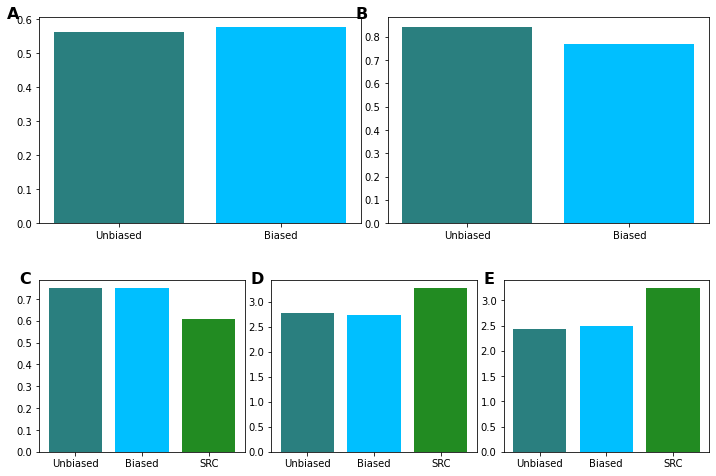

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create figure and GridSpec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[1.2, 1], hspace=0.3, wspace=0.3)

# First row - 2 larger charts
ax_a = fig.add_subplot(gs[0, 0:3])  # Spans first 2 columns
ax_b = fig.add_subplot(gs[0, 3:])    # Third column

# Second row - 3 charts
ax_c = fig.add_subplot(gs[1, 0:2])
ax_d = fig.add_subplot(gs[1, 2:4])
ax_e = fig.add_subplot(gs[1, 4:])

axes = [ax_a, ax_b, ax_c, ax_d, ax_e]
labels = ['A', 'B', 'C', 'D', 'E']
xs = [plot_order[:2], plot_order[:2], plot_order, plot_order, plot_order]
ys = [average_kinase_values[:2], max_kinase_values[:2], average_qed, average_sas, average_logP]

# Add labels and your bar charts
i = 0
for ax, label in zip(axes, labels):
    # Add your bar chart code here
    ax.bar(xs[i], ys[i], color=colors)
    
    # Add subplot label
    ax.text(-0.1, 1.05, label, transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='top')
    i+= 1

plt.tight_layout()
plt.show()

### Molecular Properties

In [103]:
def plot_properties(data, xlabel, ylabel, savefig = False, figsize = (15,15)):
    ''' Plot the molecular properties'''
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, (title, values), color in zip(axes, data.items(), colors):
        ax.hist(values, bins=10, color=color, linewidth=0.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f'({chr(65 + list(data.keys()).index(title))}) {title}', 
                     fontsize=10, pad=10)
        ax.grid(False)

    #plt.tight_layout()
    plt.show()
    if(savefig == True):
        plt.savefig(f'figures/{xlabel}.png')

LaputeASA


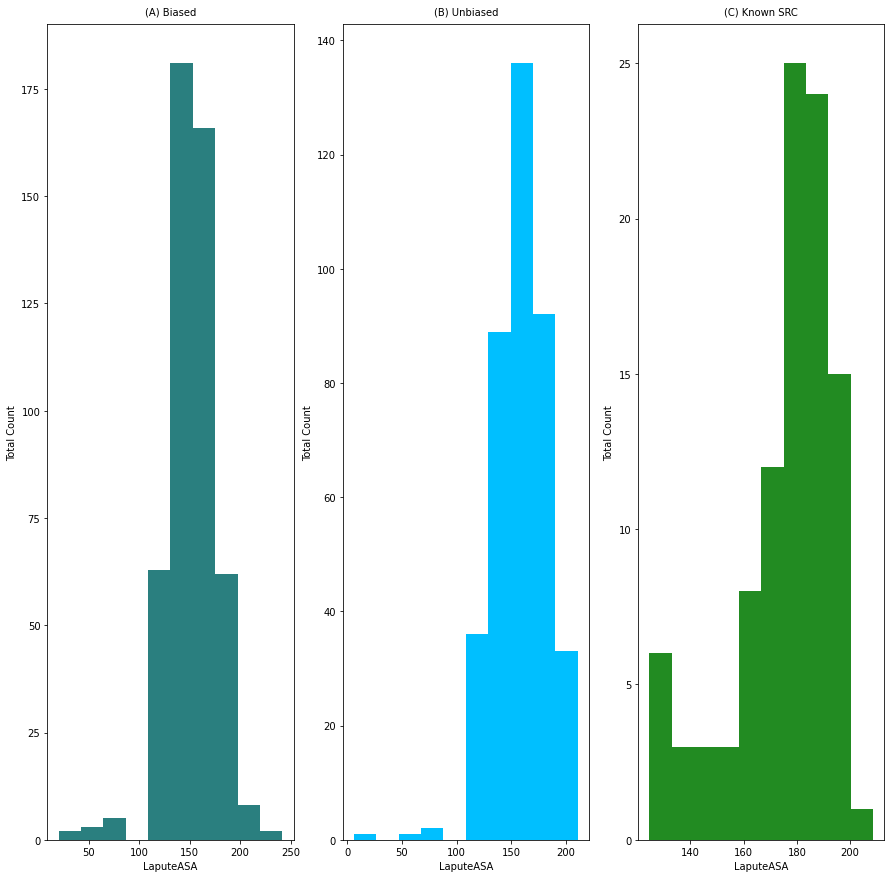

Weight


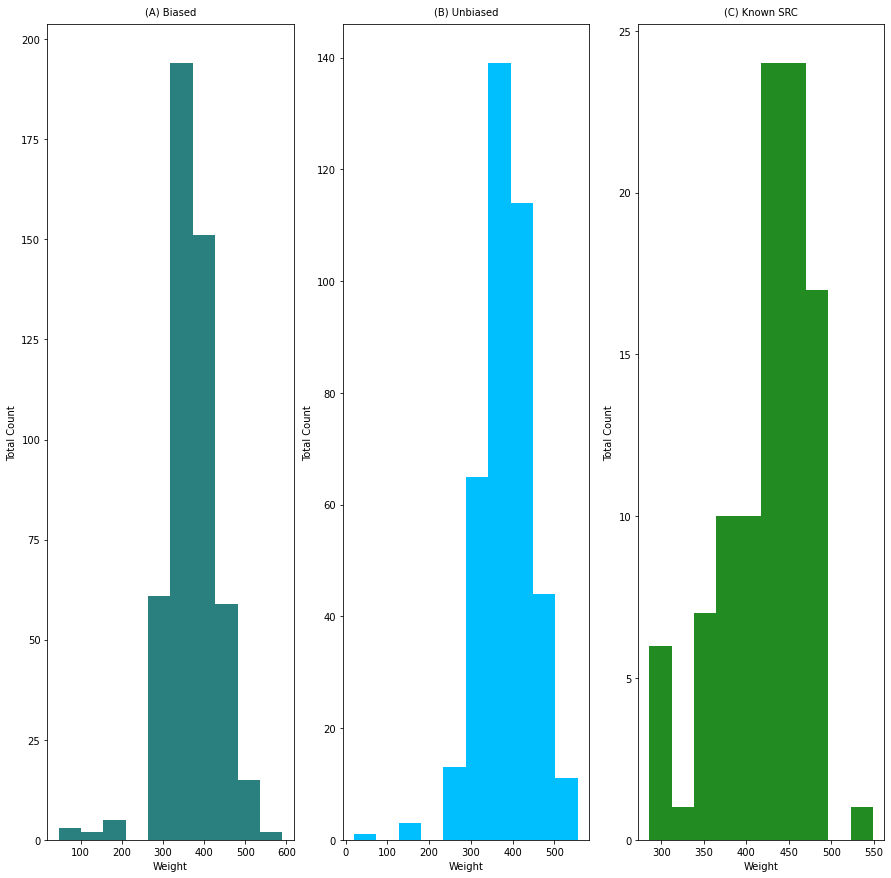

Aromatic Rings


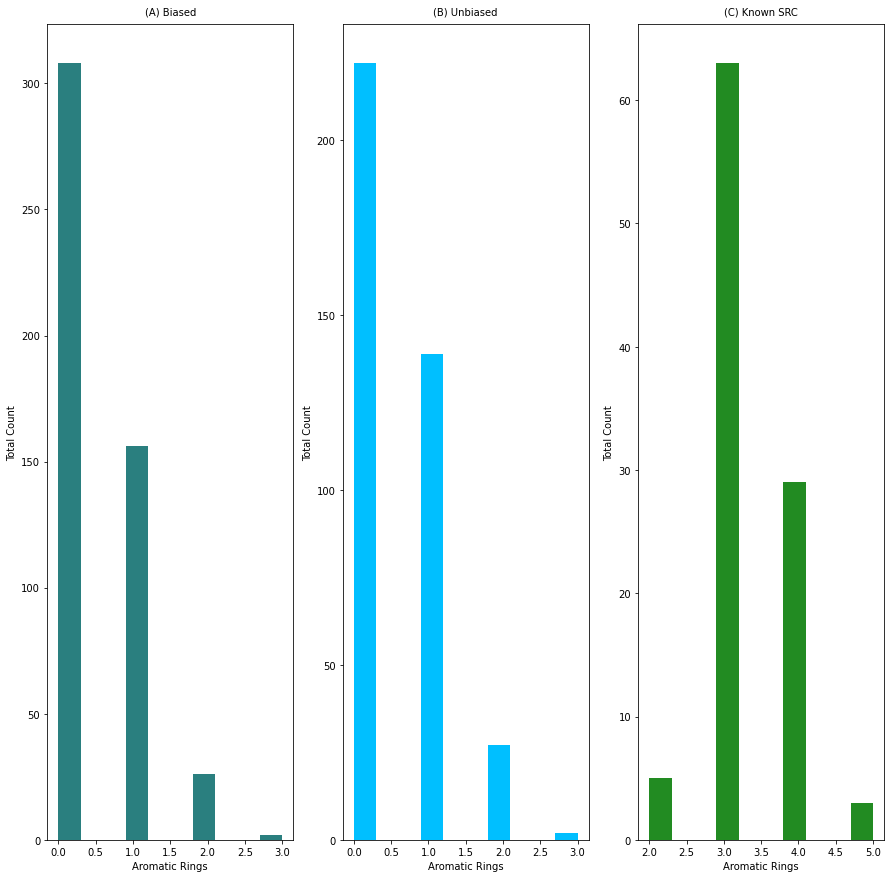

Aromatic Carbocycles


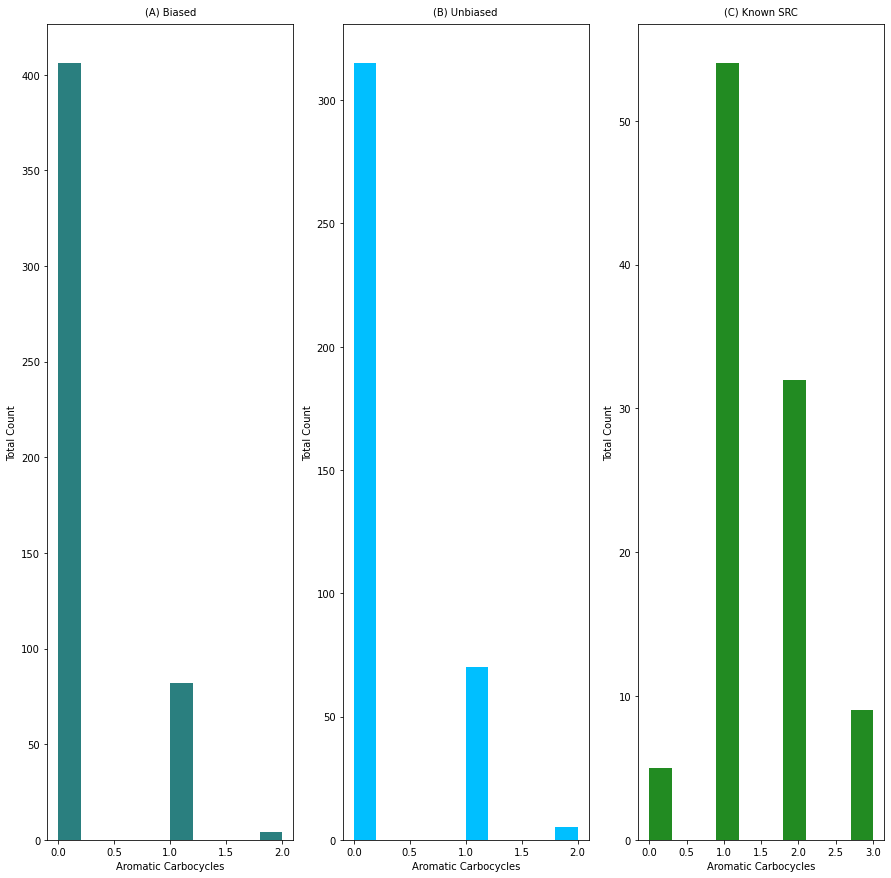

In [102]:
print('LaputeASA')
plot_properties(laputeASA, 'LaputeASA', 'Total Count')

print('Weight')
plot_properties(weight, 'Weight', 'Total Count')

print('Aromatic Rings')
plot_properties(aro_rings, 'Aromatic Rings', 'Total Count')

print('Aromatic Carbocycles')
plot_properties(aro_carbo, 'Aromatic Carbocycles', 'Total Count')

## Reading in Data to calculate Class Assignment

In [12]:
class_data = pd.read_csv('data/all_classes_with_likelihood.csv', header=0)
class_data.head()

,smiles,qed,SAS,logP,mol,class,src,rings,weight,csp3,...,amidebonds,arocarbo,arohetero,arorings,stereocenter,bridgehead,hba,hbd,rotatable,kinase likelihood
0,CC12CC3(C)C(CC1(N2)C#C)=CCC3=NO,0.784331,4.807009,1.715781,"<img data-content=""rdkit/molecule"" src=""data:i...",10,0,3,216.126263,0.615385,...,0,0,0,0,3,0,3,2,0,0.0
1,CC12CC(CC#C)(CCCC1)C1=NNN=C1O2,0.822689,3.942670,2.333623,"<img data-content=""rdkit/molecule"" src=""data:i...",10,0,3,231.137162,0.692308,...,0,0,1,1,2,2,3,1,1,0.0
2,BrC1=NC=NC2=C1C=C(C(=O)CC#C)C(=O)N2,0.768854,2.829627,1.119034,"<img data-content=""rdkit/molecule"" src=""data:i...",10,0,2,290.964339,0.090909,...,0,0,2,2,0,0,4,1,2,0.0
3,CC12CC(NC11CNC1)C(=O)C=CCC#C2,0.748343,4.331631,0.693543,"<img data-content=""rdkit/molecule"" src=""data:i...",10,0,3,216.126263,0.615385,...,0,0,0,0,2,2,3,2,0,0.0
4,CC1(C)C2CC3CC(CN12)C(=NO)C3C=NO,0.755892,4.982931,0.949449,"<img data-content=""rdkit/molecule"" src=""data:i...",10,0,3,237.147727,0.833333,...,0,0,0,0,5,2,5,2,1,0.0


In [11]:
class_values = {
    'MAPK14' : max(class_data[class_data['class'] == 8]['kinase likelihood'].values),
    'ABL1' : max(class_data[class_data['class'] == 0]['kinase likelihood'].values),
    'KDR' : max(class_data[class_data['class'] == 5]['kinase likelihood'].values),
    'LCK' : max(class_data[class_data['class'] == 6]['kinase likelihood'].values),
    'MAPK10' : max(class_data[class_data['class'] == 7]['kinase likelihood'].values),
    'CSF1R' : max(class_data[class_data['class'] == 2]['kinase likelihood'].values),
    'MET' : max(class_data[class_data['class'] == 9]['kinase likelihood'].values),
    'FLT3' : max(class_data[class_data['class'] == 4]['kinase likelihood'].values),
    'EGFR' : max(class_data[class_data['class'] == 3]['kinase likelihood'].values)
}

([<matplotlib.axis.XTick at 0x127d590ab60>,
 [Text(0, 0, 'MAPK14'),
  Text(1, 0, 'ABL1'),
  Text(2, 0, 'KDR'),
  Text(3, 0, 'LCK'),
  Text(4, 0, 'MAPK10'),
  Text(5, 0, 'CSF1R'),
  Text(6, 0, 'MET'),
  Text(7, 0, 'FLT3'),
  Text(8, 0, 'EGFR')])

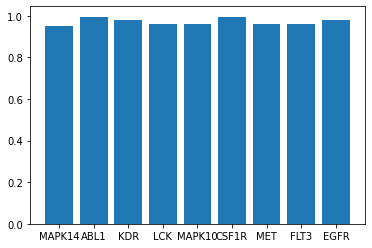

In [12]:
plt.bar(range(len(class_values)), list(class_values.values()), align='center')
plt.xticks(range(len(class_values)), list(class_values.keys()))